In [56]:
# 라이브러리
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [57]:
# 데이터 불러오기
df = pd.read_csv('/content/drive/MyDrive/abalone.csv')
df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [74]:
df['Rings'].value_counts().sort_index()

,count
Rings,
1,1
2,1
3,15
4,57
5,115
6,259
7,391
8,568
9,689


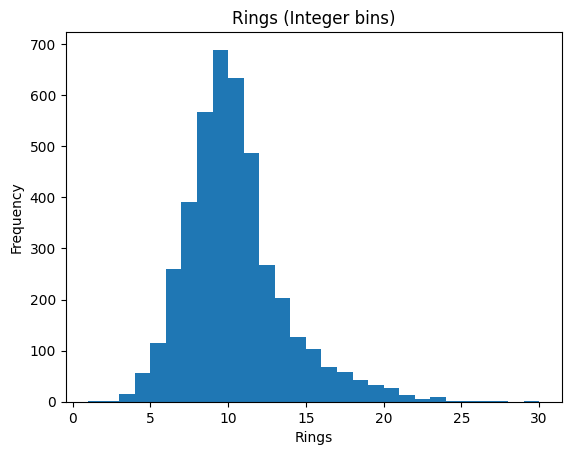

In [76]:
#Rings 값의 분포 확인
plt.hist(df['Rings'], bins=range(1,31))
plt.xlabel("Rings")
plt.ylabel("Frequency")
plt.title("Rings (Integer bins)")
plt.show()

In [59]:
#Sex 데이터는 딥러닝이 학습할 수 없는 문자 데이터이기에 숫자 형태로 변환
df = pd.get_dummies(df, columns=['Sex'], drop_first=True)

In [60]:
#만약 정확한 값으로 전복의 나이를 분류할 경우 클래스 수가 너무 많아짐
#각 클래스 간의 차이가 미세하기 때문에 학습하기가 어려워짐
#또한 데이터가 5~15 구간에 집중되어 있어 일부 클래스는 데이터가 부족
#이를 해결해기 위해 몇 개의 구간으로 나누어 분류 문제를 진행

# Rings 값을 기준으로 전복의 나이를 세 개의 구간으로 설정
# 0 ~ 8 : 어린 개체
# 9 ~ 15 : 중간 개체
# 16 ~ 30 : 오래된 개체

df['AgeClass'] = pd.cut(
    df['Rings'],
    bins=[0, 8, 15, 30],
    labels=[0, 1, 2]
)

In [61]:
#딥러닝 입력을 위해 Numpy로 변환: .values
X = df.drop(['Rings', 'AgeClass'], axis=1).values
y = df['AgeClass'].astype(int).values

In [62]:
X

array([[0, 0.455, 0.365, ..., 0.15, False, True],
       [1, 0.35, 0.265, ..., 0.07, False, True],
       [2, 0.53, 0.42, ..., 0.21, False, False],
       ...,
       [4174, 0.6, 0.475, ..., 0.308, False, True],
       [4175, 0.625, 0.485, ..., 0.296, False, False],
       [4176, 0.71, 0.555, ..., 0.495, False, True]], dtype=object)

In [63]:
y

array([1, 0, 1, ..., 1, 1, 1])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [65]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape,

((3341, 10), (3341,), (836, 10), (836,))

In [66]:
#아발론 데이터에서는 feature마다 값의 크기가 달라서
#스케일링을 하지 않을 경우 값이 큰 feature를 더 중요하다고 착각하여 값이 과도하게 반영이 될 수 있음
#그래서 모든 feature를 균형있게 학습하기 위해 StandardScaler 사용

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [67]:
#모델 정의
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')  # 클래스 3개(어린, 중간, 오래된)
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,643 (18.14 KB)

 Trainable params: 4,643 (18.14 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
#모델이 학습을 오래할 수록 데이터에 과적합할 가능성이 증가
#이를 방지하기 위해 손실을 기준으로 성능 개선이 되지 않는 다면 학습을 조기에 종료
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

In [69]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7240 - loss: 0.7357 - val_accuracy: 0.7787 - val_loss: 0.6003
Epoch 2/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7689 - loss: 0.5827 - val_accuracy: 0.7799 - val_loss: 0.5649
Epoch 3/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7746 - loss: 0.5592 - val_accuracy: 0.7919 - val_loss: 0.5421
Epoch 4/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7728 - loss: 0.5457 - val_accuracy: 0.7919 - val_loss: 0.5323
Epoch 5/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7803 - loss: 0.5314 - val_accuracy: 0.7871 - val_loss: 0.5206
Epoch 6/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7809 - loss: 0.5187 - val_accuracy: 0.7799 - val_loss: 0.5168
Epoch 7/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7812 - loss: 0.5096 - val_accuracy: 0.7907 - val_loss: 0.5030
Epoch 8/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7839 - loss: 0.5028 - val_acc

In [70]:
y_pred = model.predict(X_test)

# 확률 → 가장 큰 값의 인덱스 선택
y_pred_class = np.argmax(y_pred, axis=1)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


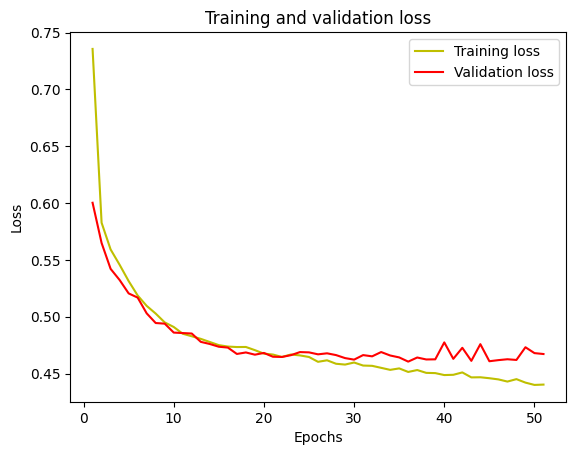

In [71]:
# loss 그래프
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

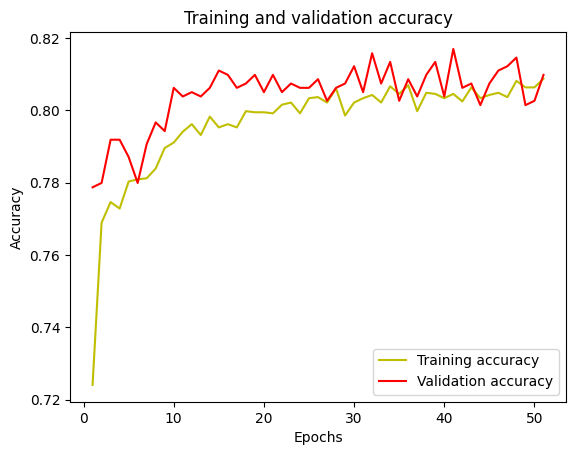

In [72]:
# accuracy 그래프
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, 'y', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [73]:
print(classification_report(y_test, y_pred_class))
print(confusion_matrix(y_test, y_pred_class))

              precision    recall  f1-score   support

           0       0.85      0.77      0.81       307
           1       0.79      0.90      0.84       478
           2       0.57      0.24      0.33        51

    accuracy                           0.81       836
   macro avg       0.74      0.63      0.66       836
weighted avg       0.80      0.81      0.80       836

[[235  72   0]
 [ 40 429   9]
 [  0  39  12]]
